# ANAC Bandi di Gara — Procedure e spesa della PA italiana
Dataset: `anac_bandi_gara` (2023-2025)

Analisi: come la PA italiana affida i contratti pubblici, quanto spende, e quali procedure usa.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

# Legge i 3 anni
path_template = "gs://dataciviclab-clean/anac_bandi_gara/{y}/anac_bandi_gara_{y}_clean.parquet"
for y in [2023, 2024, 2025]:
    p = path_template.format(y=y)
    con.execute(f"CREATE VIEW anac_{y} AS SELECT * FROM read_parquet('{p}')")
con.execute("CREATE VIEW anac_all AS SELECT * FROM anac_2023 UNION ALL SELECT * FROM anac_2024 UNION ALL SELECT * FROM anac_2025")
print("Dati caricati")

Dati caricati


In [2]:
# 1. Quadro generale
df = con.execute("""
    SELECT anno_pubblicazione AS anno,
           COUNT(*) AS n_lotti,
           COUNT(DISTINCT cig) AS n_gare,
           ROUND(SUM(importo_lotto)) AS importo_totale,
           ROUND(AVG(importo_lotto)) AS importo_medio,
           ROUND(MEDIAN(importo_lotto)) AS importo_mediano
    FROM anac_all
    GROUP BY anno_pubblicazione
    ORDER BY anno_pubblicazione
""").fetchdf()
df['importo_totale'] = (df['importo_totale'] / 1e9).round(1)
df['importo_medio'] = (df['importo_medio'] / 1e3).round(0).astype(int)
df['importo_mediano'] = (df['importo_mediano'] / 1e3).round(0).astype(int)
print(df.to_markdown(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

|   anno |          n_lotti |           n_gare |   importo_totale |   importo_medio |   importo_mediano |
|-------:|-----------------:|-----------------:|-----------------:|----------------:|------------------:|
|   2023 | 655125           | 655125           |            404.2 |             617 |                56 |
|   2024 |      1.22891e+06 |      1.21352e+06 |            693.8 |             565 |                17 |
|   2025 |      1.47558e+06 |      1.45392e+06 |            634.7 |             430 |                17 |


In [3]:
# 2. Procedure di scelta del contraente — TOP 10 per anno
df_proc = con.execute("""
    SELECT anno_pubblicazione AS anno,
           tipo_scelta_contraente,
           COUNT(*) AS n_lotti,
           ROUND(SUM(importo_lotto)) AS importo_totale,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY anno_pubblicazione), 1) AS perc_lotti,
           ROUND(SUM(importo_lotto) * 100.0 / SUM(SUM(importo_lotto)) OVER (PARTITION BY anno_pubblicazione), 1) AS perc_importo
    FROM anac_all
    WHERE tipo_scelta_contraente IS NOT NULL
    GROUP BY anno_pubblicazione, tipo_scelta_contraente
    ORDER BY anno_pubblicazione, importo_totale DESC
""").fetchdf()
df_proc['importo_totale'] = (df_proc['importo_totale'] / 1e9).round(1)
# Per anno, mostra le prime 6 procedure
for anno in [2023, 2024, 2025]:
    print(f"\n### {anno}")
    print(df_proc[df_proc['anno'] == anno].head(8).to_markdown(index=False, floatfmt='.1f'))


### 2023
|   anno | tipo_scelta_contraente                                                |   n_lotti |   importo_totale |   perc_lotti |   perc_importo |
|-------:|:----------------------------------------------------------------------|----------:|-----------------:|-------------:|---------------:|
|   2023 | PROCEDURA APERTA                                                      |     70313 |            170.4 |         10.7 |           42.2 |
|   2023 | AFFIDAMENTO DIRETTO IN ADESIONE AD ACCORDO QUADRO/CONVENZIONE         |    124885 |             75.7 |         19.1 |           18.7 |
|   2023 | PROCEDURA RISTRETTA                                                   |     20632 |             42.4 |          3.1 |           10.5 |
|   2023 | AFFIDAMENTO DIRETTO                                                   |    327359 |             31.4 |         50.0 |            7.8 |
|   2023 | PROCEDURA NEGOZIATA PER AFFIDAMENTI SOTTO SOGLIA                      |     69790 |             22.9 | 

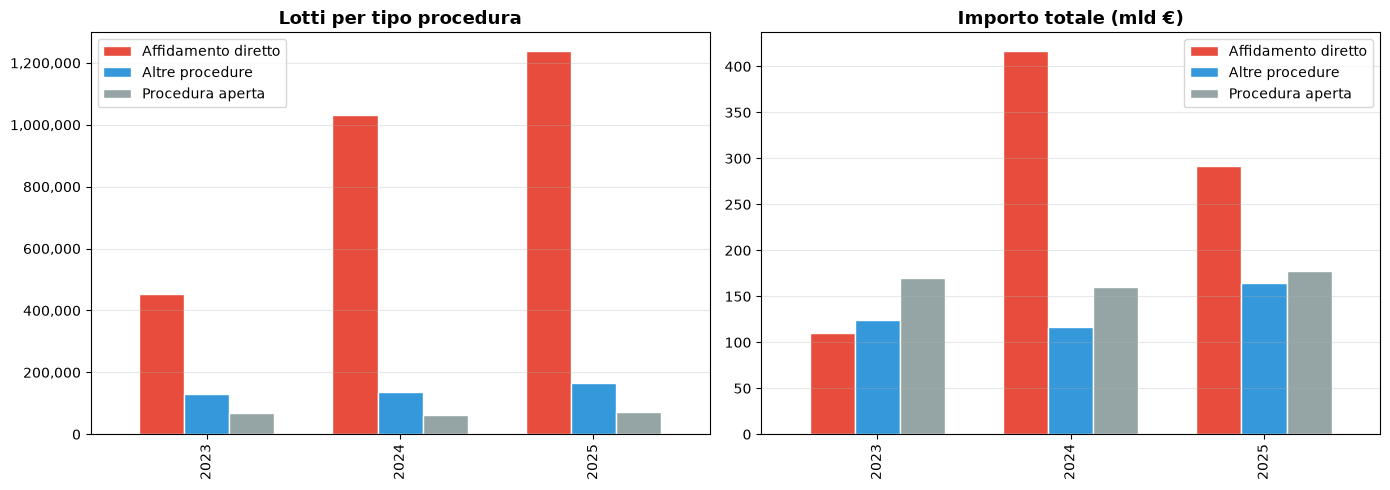

In [4]:
# 3. Grafico: confronto affidamento diretto vs procedure aperte (2023-2025)
df_confronto = con.execute("""
    SELECT anno_pubblicazione AS anno,
           CASE WHEN tipo_scelta_contraente IN ('AFFIDAMENTO DIRETTO') THEN 'Affidamento diretto'
                WHEN tipo_scelta_contraente IN ('PROCEDURA APERTA') THEN 'Procedura aperta'
                WHEN tipo_scelta_contraente LIKE 'AFFIDAMENTO DIRETTO%' THEN 'Affidamento diretto'
                ELSE 'Altre procedure' END AS categoria,
           COUNT(*) AS n_lotti,
           SUM(importo_lotto) AS importo_totale
    FROM anac_all
    WHERE tipo_scelta_contraente IS NOT NULL
    GROUP BY anno, categoria
    ORDER BY anno, categoria
""").fetchdf()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, fmt in [
    (ax1, 'n_lotti', 'Lotti per tipo procedura', '{x:.0f}'),
    (ax2, 'importo_totale', 'Importo totale (mld €)', '{x:.0f}')
]:
    pivot = df_confronto.pivot(index='anno', columns='categoria', values=metric)
    if metric == 'importo_totale':
        pivot = pivot / 1e9
    colors = ['#e74c3c', '#3498db', '#95a5a6']
    pivot.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(title='', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/appalti_confronto_procedure.png', dpi=150, bbox_inches='tight')
plt.show()

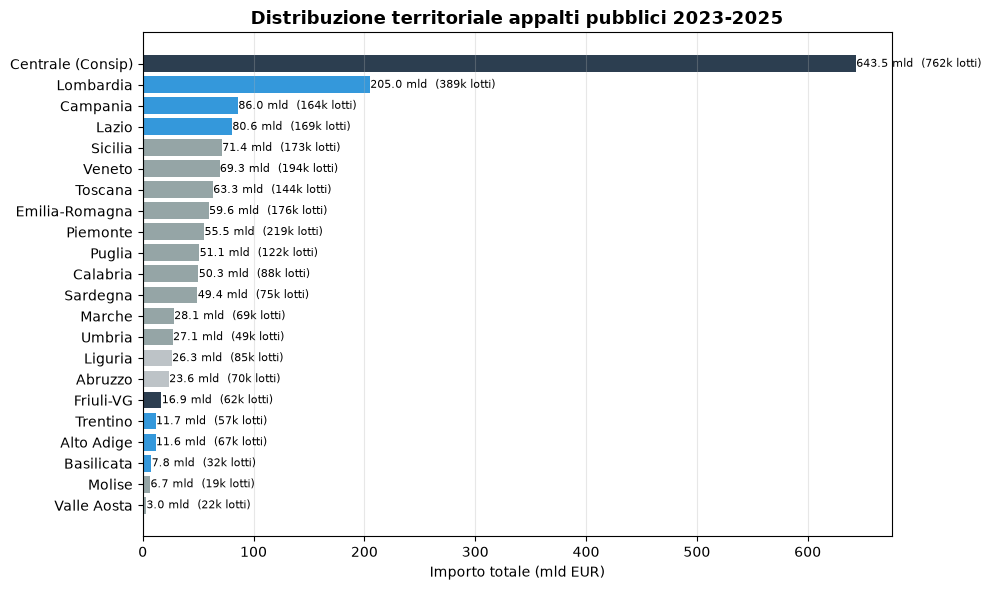

In [5]:
# 4. Distribuzione geografica (2023-2025 aggregato)
df_geo = con.execute("""
    WITH geo AS (
        SELECT CASE 
            WHEN sezione_regionale LIKE '%CENTRALE%' THEN 'Centrale (Consip)'
            WHEN sezione_regionale LIKE '%LOMBARDIA%' THEN 'Lombardia'
            WHEN sezione_regionale LIKE '%CAMPANIA%' THEN 'Campania'
            WHEN sezione_regionale LIKE '%SICILIA%' THEN 'Sicilia'
            WHEN sezione_regionale LIKE '%LAZIO%' THEN 'Lazio'
            WHEN sezione_regionale LIKE '%VENETO%' THEN 'Veneto'
            WHEN sezione_regionale LIKE '%TOSCANA%' THEN 'Toscana'
            WHEN sezione_regionale LIKE '%PIEMONTE%' THEN 'Piemonte'
            WHEN sezione_regionale LIKE '%EMILIA%' THEN 'Emilia-Romagna'
            WHEN sezione_regionale LIKE '%PUGLIA%' THEN 'Puglia'
            WHEN sezione_regionale LIKE '%SARDEGNA%' THEN 'Sardegna'
            WHEN sezione_regionale LIKE '%ABRUZZO%' THEN 'Abruzzo'
            WHEN sezione_regionale LIKE '%LIGURIA%' THEN 'Liguria'
            WHEN sezione_regionale LIKE '%MARCHE%' THEN 'Marche'
            WHEN sezione_regionale LIKE '%CALABRIA%' THEN 'Calabria'
            WHEN sezione_regionale LIKE '%UMBRIA%' THEN 'Umbria'
            WHEN sezione_regionale LIKE '%FRIULI%' THEN 'Friuli-VG'
            WHEN sezione_regionale LIKE '%TRENTO%' THEN 'Trentino'
            WHEN sezione_regionale LIKE '%BOLZANO%' THEN 'Alto Adige'
            WHEN sezione_regionale LIKE '%MOLISE%' THEN 'Molise'
            WHEN sezione_regionale LIKE '%BASILICATA%' THEN 'Basilicata'
            WHEN sezione_regionale LIKE '%AOSTA%' THEN 'Valle Aosta'
            ELSE 'Altro' END AS area,
            importo_lotto
        FROM anac_all
        WHERE sezione_regionale NOT IN ('NON CLASSIFICATO', 'ESTERO')
    )
    SELECT area,
           COUNT(*) AS n_lotti,
           ROUND(SUM(importo_lotto)) AS importo_totale
    FROM geo
    GROUP BY area
    ORDER BY importo_totale DESC
""").fetchdf()
df_geo['importo_totale'] = (df_geo['importo_totale'] / 1e9).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
colors_geo = ['#2c3e50'] + ['#3498db']*3 + ['#95a5a6']*10 + ['#bdc3c7']*2
bars = ax.barh(range(len(df_geo)), df_geo['importo_totale'].values, color=colors_geo[:len(df_geo)])
ax.set_yticks(range(len(df_geo)))
ax.set_yticklabels(df_geo['area'].values)
ax.set_xlabel('Importo totale (mld EUR)')
ax.set_title('Distribuzione territoriale appalti pubblici 2023-2025', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for i, (v, n) in enumerate(zip(df_geo['importo_totale'], df_geo['n_lotti'])):
    ax.text(v + 0.3, i, f'{v} mld  ({n/1000:.0f}k lotti)', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/appalti_distribuzione_territoriale.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 5. PNRR
df_pnrr = con.execute("""
    SELECT flag_pnrr,
           COUNT(*) AS n_lotti,
           ROUND(SUM(importo_lotto)) AS importo_totale,
           ROUND(AVG(importo_lotto)) AS importo_medio
    FROM anac_all
    GROUP BY flag_pnrr
""").fetchdf()
df_pnrr['importo_totale'] = (df_pnrr['importo_totale'] / 1e9).round(1)
df_pnrr['importo_medio'] = (df_pnrr['importo_medio'] / 1e3).round(0).astype(int)

# PNRR per regione
df_pnrr_geo = con.execute("""
    SELECT CASE 
        WHEN sezione_regionale = 'SEZIONE REGIONALE CENTRALE' THEN 'Centrale (Consip)'
        WHEN sezione_regionale = 'SEZIONE REGIONALE LOMBARDIA' THEN 'Lombardia'
        ELSE 'Altre regioni' END AS area,
        ROUND(SUM(importo_lotto)) AS importo_pnrr,
        ROUND(SUM(importo_lotto) * 100.0 / (SELECT SUM(importo_lotto) FROM anac_all WHERE flag_pnrr = true), 1) AS perc
    FROM anac_all
    WHERE flag_pnrr = true
    GROUP BY area
    ORDER BY importo_pnrr DESC
""").fetchdf()
df_pnrr_geo['importo_pnrr'] = (df_pnrr_geo['importo_pnrr'] / 1e9).round(1)

print("PNRR — volumi")
print(df_pnrr.to_markdown(index=False, floatfmt='.1f'))
print("\nPNRR — distribuzione")
print(df_pnrr_geo.to_markdown(index=False, floatfmt='.1f'))

PNRR — volumi
| flag_pnrr   |   n_lotti |   importo_totale |   importo_medio |
|:------------|----------:|-----------------:|----------------:|
| False       |   3058118 |           1577.2 |             516 |
| True        |    301497 |            155.5 |             516 |

PNRR — distribuzione
| area              |   importo_pnrr |   perc |
|:------------------|---------------:|-------:|
| Centrale (Consip) |           75.0 |   48.3 |
| Altre regioni     |           70.6 |   45.4 |
| Lombardia         |            9.9 |    6.3 |


In [7]:
# 6. Urgenza
df_urg = con.execute("""
    SELECT anno_pubblicazione AS anno,
           flag_urgenza,
           COUNT(*) AS n_lotti,
           ROUND(SUM(importo_lotto)) AS importo_totale,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY anno_pubblicazione), 1) AS perc_lotti
    FROM anac_all
    GROUP BY anno, flag_urgenza
    ORDER BY anno, flag_urgenza
""").fetchdf()
df_urg['importo_totale'] = (df_urg['importo_totale'] / 1e9).round(1)
print(df_urg.to_markdown(index=False, floatfmt='.1f'))

|   anno | flag_urgenza   |   n_lotti |   importo_totale |   perc_lotti |
|-------:|:---------------|----------:|-----------------:|-------------:|
|   2023 | False          |    648590 |            400.6 |         99.0 |
|   2023 | True           |      6535 |              3.5 |          1.0 |
|   2024 | False          |    391173 |            385.0 |         31.8 |
|   2024 | True           |    837736 |            308.8 |         68.2 |
|   2025 | False          |    476473 |            347.4 |         32.3 |
|   2025 | True           |    999108 |            287.4 |         67.7 |


In [8]:
# 7. Categorie merceologiche
df_cat = con.execute("""
    SELECT oggetto_principale_contratto AS categoria,
           COUNT(*) AS n_lotti,
           ROUND(SUM(importo_lotto)) AS importo_totale,
           ROUND(AVG(importo_lotto)) AS importo_medio
    FROM anac_all
    GROUP BY categoria
    ORDER BY importo_totale DESC
""").fetchdf()
df_cat['importo_totale'] = (df_cat['importo_totale'] / 1e9).round(1)
df_cat['importo_medio'] = (df_cat['importo_medio'] / 1e3).round(0).astype(int)
print(df_cat.to_markdown(index=False, floatfmt='.1f'))

| categoria   |   n_lotti |   importo_totale |   importo_medio |
|:------------|----------:|-----------------:|----------------:|
| FORNITURE   |   1452162 |            780.6 |             538 |
| SERVIZI     |   1481890 |            648.0 |             437 |
| LAVORI      |    425553 |            304.1 |             715 |
| nan         |        10 |              0.0 |            1588 |


In [9]:
# 8. Affidamento diretto vs procedure competitive per regione
df_reg_proc = con.execute("""
    SELECT CASE 
        WHEN sezione_regionale = 'SEZIONE REGIONALE CENTRALE' THEN 'Centrale'
        WHEN sezione_regionale = 'SEZIONE REGIONALE LOMBARDIA' THEN 'Lombardia'
        WHEN sezione_regionale = 'SEZIONE REGIONALE CAMPANIA' THEN 'Campania'
        WHEN sezione_regionale = 'SEZIONE REGIONALE SICILIA' THEN 'Sicilia'
        ELSE 'Altre regioni' END AS area,
       CASE WHEN tipo_scelta_contraente IN ('AFFIDAMENTO DIRETTO') OR tipo_scelta_contraente LIKE 'AFFIDAMENTO DIRETTO%' 
            THEN 'Affidamento diretto' ELSE 'Procedure competitive' END AS tipo,
       COUNT(*) AS n_lotti,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY 
           CASE WHEN sezione_regionale = 'SEZIONE REGIONALE CENTRALE' THEN 'Centrale'
                WHEN sezione_regionale = 'SEZIONE REGIONALE LOMBARDIA' THEN 'Lombardia'
                WHEN sezione_regionale = 'SEZIONE REGIONALE CAMPANIA' THEN 'Campania'
                WHEN sezione_regionale = 'SEZIONE REGIONALE SICILIA' THEN 'Sicilia'
                ELSE 'Altre regioni' END), 1) AS perc_lotti
    FROM anac_all
    WHERE sezione_regionale NOT IN ('NON CLASSIFICATO', 'ESTERO')
      AND tipo_scelta_contraente IS NOT NULL
    GROUP BY area, tipo
    ORDER BY area, tipo
""").fetchdf()
print(df_reg_proc.to_markdown(index=False, floatfmt='.1f'))

| area          | tipo                  |   n_lotti |   perc_lotti |
|:--------------|:----------------------|----------:|-------------:|
| Altre regioni | Affidamento diretto   |   1386026 |         80.6 |
| Altre regioni | Procedure competitive |    333628 |         19.4 |
| Campania      | Affidamento diretto   |    116392 |         70.8 |
| Campania      | Procedure competitive |     47913 |         29.2 |
| Centrale      | Affidamento diretto   |    631951 |         83.0 |
| Centrale      | Procedure competitive |    129568 |         17.0 |
| Lombardia     | Affidamento diretto   |    330541 |         84.9 |
| Lombardia     | Procedure competitive |     58778 |         15.1 |
| Sicilia       | Affidamento diretto   |    134364 |         77.6 |
| Sicilia       | Procedure competitive |     38835 |         22.4 |


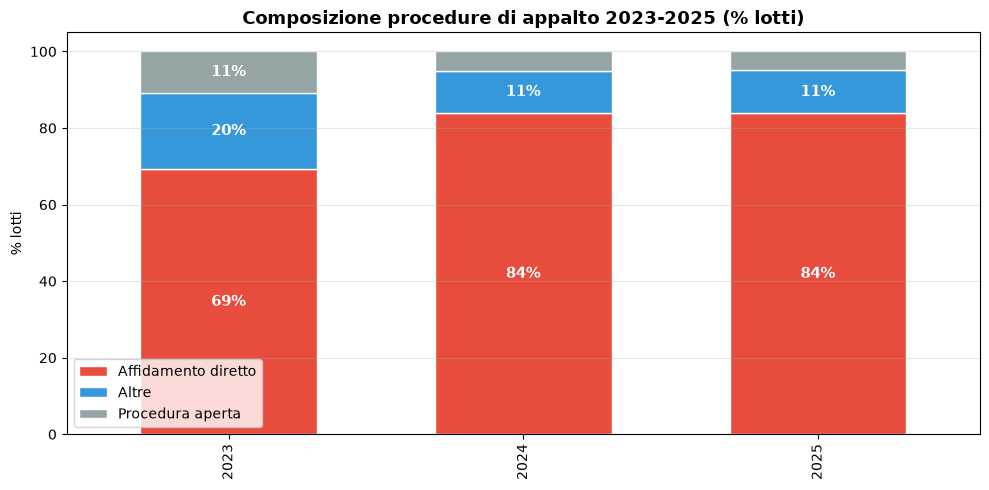

In [10]:
# 9. Figura: evoluzione procedure 2023-2025
df_trend = con.execute("""
    SELECT anno_pubblicazione AS anno,
           CASE WHEN tipo_scelta_contraente IN ('AFFIDAMENTO DIRETTO') OR tipo_scelta_contraente LIKE 'AFFIDAMENTO DIRETTO%' 
                THEN 'Affidamento diretto'
                WHEN tipo_scelta_contraente IN ('PROCEDURA APERTA') THEN 'Procedura aperta'
                ELSE 'Altre' END AS categoria,
           COUNT(*) AS n_lotti
    FROM anac_all
    WHERE tipo_scelta_contraente IS NOT NULL
    GROUP BY anno, categoria
    ORDER BY anno, categoria
""").fetchdf()

pivot = df_trend.pivot(index='anno', columns='categoria', values='n_lotti')
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#95a5a6']
pivot_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Composizione procedure di appalto 2023-2025 (% lotti)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% lotti')
ax.legend(title='', fontsize=10)
ax.grid(axis='y', alpha=0.3)
for i in range(len(pivot_pct)):
    cum = 0
    for j, col in enumerate(pivot_pct.columns):
        val = pivot_pct.iloc[i, j]
        if val > 5:
            ax.text(i, cum + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        cum += val
plt.tight_layout()
plt.savefig('../figures/appalti_evoluzione_procedure.png', dpi=150, bbox_inches='tight')
plt.show()